In [1]:
#Baris ini untuk setup library

import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from wordcloud import WordCloud

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
#Ini untuk membaca dataset yang diberikan. Kali ini dataset berbahasa Inggris

df_en = pd.read_csv("data/data_en.csv")


df_en['text'] = df_en['Sentence']
df_en['label'] = df_en['Sentiment']

df_en.head()

,Sentence,Sentiment,text,label
0,The GeoSolutions technology will leverage Bene...,positive,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral,The Swedish buyout firm has sold its remaining...,neutral


<function matplotlib.pyplot.show(close=None, block=None)>

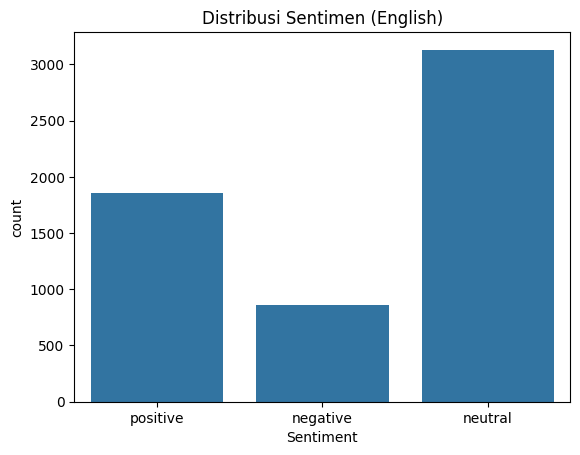

In [3]:
#Ini untuk melihat jumlah sebaran sentimen yang tercatat pada data

sns.countplot(x='Sentiment', data=df_en)
plt.title("Distribusi Sentimen (English)")
plt.show

In [4]:
#Text Processing 

stop_words_en = set(stopwords.words('english'))
stemmer_en = PorterStemmer()

def preprocess_en(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words_en]
    tokens = [stemmer_en.stem(w) for w in tokens]
    return " ".join(tokens)

df_en['clean_text'] = df_en['text'].apply(preprocess_en)


In [5]:
# Proses Feature Extraction

X_train_en, X_test_en, y_train_en, y_test_en = train_test_split(df_en['clean_text'], df_en['label'], test_size=0.2, random_state=42)

bow_en = CountVectorizer() # Bagian Ini merupakan proses Bag of Words

X_train_bow_en = bow_en.fit_transform(X_train_en)
X_test_bow_en = bow_en.transform(X_test_en)

tfidf_en = TfidfVectorizer() # Bagian ini merupakan proses TF-IDF

X_train_tfidf_en = tfidf_en.fit_transform(X_train_en)
X_test_tfidf_en = tfidf_en.transform(X_test_en)


In [6]:
# Mencetak hasil akurasi BoW dan TF-IDF menggunakan Naive Bayes

model_bow_en = MultinomialNB() # Bagian BoW
model_bow_en.fit(X_train_bow_en, y_train_en)

pred_bow_en = model_bow_en.predict(X_test_bow_en)

acc_bow_en = accuracy_score(y_test_en, pred_bow_en)
print("Akurasi EN BoW: ", acc_bow_en)
print(classification_report(y_test_en, pred_bow_en))

model_tfidf_en = MultinomialNB() #Bagian TF-IDF
model_tfidf_en.fit(X_train_tfidf_en, y_train_en)

pred_tfidf_en = model_tfidf_en.predict(X_test_tfidf_en)

acc_tfidf_en = accuracy_score(y_test_en, pred_tfidf_en)
print("Akurasi EN TF-IDF: ", acc_tfidf_en)
print(classification_report(y_test_en, pred_tfidf_en))

Akurasi EN BoW:  0.7142857142857143
              precision    recall  f1-score   support

    negative       0.44      0.37      0.40       175
     neutral       0.76      0.83      0.80       622
    positive       0.74      0.68      0.71       372

    accuracy                           0.71      1169
   macro avg       0.65      0.63      0.63      1169
weighted avg       0.71      0.71      0.71      1169

Akurasi EN TF-IDF:  0.6706586826347305
              precision    recall  f1-score   support

    negative       0.80      0.05      0.09       175
     neutral       0.65      0.97      0.78       622
    positive       0.74      0.46      0.56       372

    accuracy                           0.67      1169
   macro avg       0.73      0.49      0.48      1169
weighted avg       0.70      0.67      0.61      1169



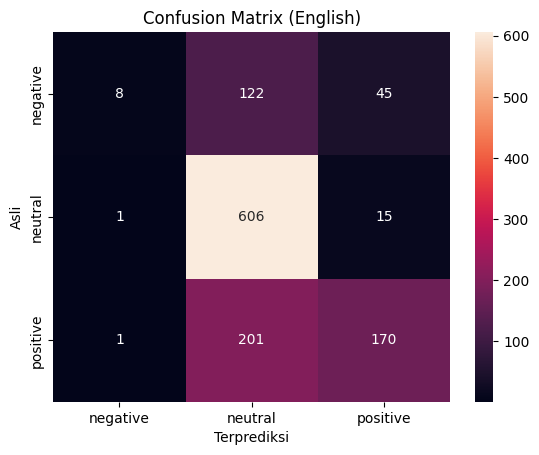

In [7]:
# Bagian Confusion Matrix, untuk mengetahui kesesuaian prediksi 

cm = confusion_matrix(y_test_en, pred_tfidf_en)

labels = sorted(df_en['label'].unique())

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Terprediksi")
plt.ylabel("Asli")
plt.title("Confusion Matrix (English)")
plt.show()

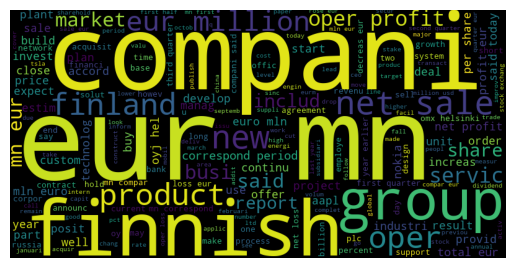

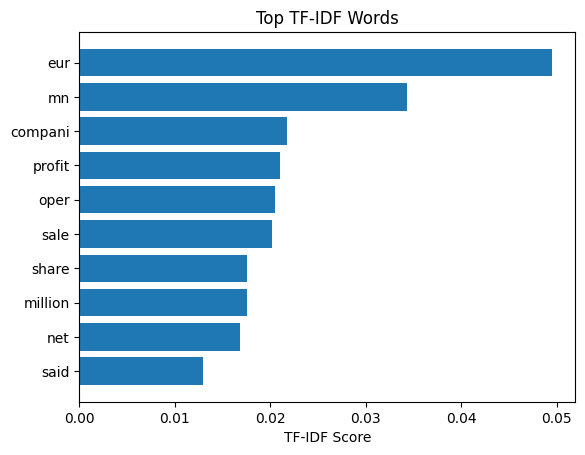

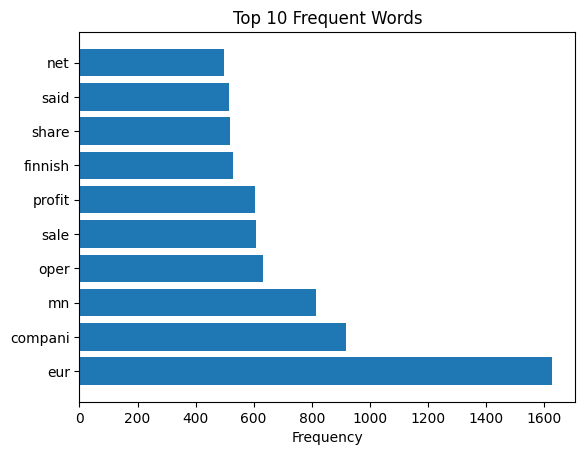

In [8]:
# Visualisasi kata-kata yang cukup sering muncul

text_all = " ".join(df_en['clean_text']) # Menggunakan WordCloud

wc = WordCloud(width=800, height=400).generate(text_all)

plt.imshow(wc)
plt.axis('off')
plt.show()

feature_names = tfidf_en.get_feature_names_out() # Menggunakan Plot TF-IDF

mean_tfidf = X_train_tfidf_en.mean(axis=0).A1

top_n = 10
top_idx = np.argsort(mean_tfidf)[-top_n:]

top_words = [feature_names[i] for i in top_idx]
top_scores = mean_tfidf[top_idx]

plt.figure()
plt.barh(top_words, top_scores)
plt.title("Top TF-IDF Words")
plt.xlabel("TF-IDF Score")
plt.show()

words = " ".join(df_en['clean_text']).split() # Menggunakan distribusi frekuensi token
word_counts = Counter(words)

top_words = word_counts.most_common(10)

w = [i[0] for i in top_words]
c = [i[1] for i in top_words]

plt.figure()
plt.barh(w, c)
plt.title("Top 10 Frequent Words")
plt.xlabel("Frequency")
plt.show()

In [9]:
#Ini untuk membaca dataset yang diberikan. Kali ini dataset berbahasa Indonesia

df_id = pd.read_csv("data/data_id.csv")

df_id['text'] = df_id['komentar']
df_id['label'] = df_id['label']

df_id.head()

,komentar,label,text
0,<username> Simulasi indonesia kembali dijajah ...,negatif,<username> Simulasi indonesia kembali dijajah ...
1,<username> <username> <username> keturunan lai...,negatif,<username> <username> <username> keturunan lai...
2,<username> <username> uda botak keturunan penj...,negatif,<username> <username> uda botak keturunan penj...
3,"<username> <username> <username> Belum tentu, ...",negatif,"<username> <username> <username> Belum tentu, ..."
4,<username> <username> <username> Lu nya aja yg...,negatif,<username> <username> <username> Lu nya aja yg...


<function matplotlib.pyplot.show(close=None, block=None)>

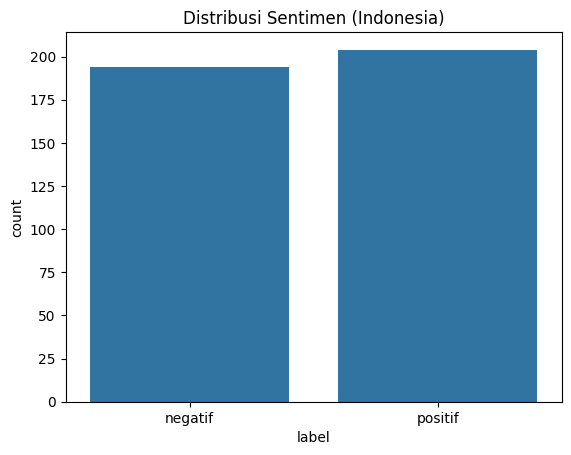

In [10]:
#Ini untuk melihat jumlah sebaran sentimen yang tercatat pada data

sns.countplot(x='label', data=df_id)
plt.title("Distribusi Sentimen (Indonesia)")
plt.show

In [11]:
#Text Processing

stop_words_id = set(stopwords.words('indonesian'))
stemmer_id = PorterStemmer()

def preprocess_id(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words_id]
    tokens = [stemmer_en.stem(w) for w in tokens]
    return " ".join(tokens)

df_id['clean_text'] = df_id['text'].apply(preprocess_id)


In [12]:
# Proses Feature Extraction

X_train_id, X_test_id, y_train_id, y_test_id = train_test_split(df_id['clean_text'], df_id['label'], test_size=0.2, random_state=42)

bow_id = CountVectorizer()

X_train_bow_id = bow_id.fit_transform(X_train_id)
X_test_bow_id = bow_id.transform(X_test_id)

tfidf_id = TfidfVectorizer()

X_train_tfidf_id = tfidf_id.fit_transform(X_train_id)
X_test_tfidf_id = tfidf_id.transform(X_test_id)


In [13]:
# Mencetak hasil akurasi BoW dan TF-IDF menggunakan Naive Bayes

model_bow_id = MultinomialNB() # Bagian BOW
model_bow_id.fit(X_train_bow_id, y_train_id)

pred_bow_id = model_bow_id.predict(X_test_bow_id)

acc_bow_id = accuracy_score(y_test_id, pred_bow_id)
print("Akurasi id BoW: ", acc_bow_id)
print(classification_report(y_test_id, pred_bow_id))

model_tfidf_id = MultinomialNB() # Bagian TF-IDF
model_tfidf_id.fit(X_train_tfidf_id, y_train_id)

pred_tfidf_id = model_tfidf_id.predict(X_test_tfidf_id)

acc_tfidf_id = accuracy_score(y_test_id, pred_tfidf_id)
print("Akurasi ID TF-IDF: ", acc_tfidf_id)
print(classification_report(y_test_id, pred_tfidf_id))

Akurasi id BoW:  0.7375
              precision    recall  f1-score   support

     negatif       0.90      0.59      0.71        44
     positif       0.65      0.92      0.76        36

    accuracy                           0.74        80
   macro avg       0.77      0.75      0.74        80
weighted avg       0.78      0.74      0.73        80

Akurasi ID TF-IDF:  0.725
              precision    recall  f1-score   support

     negatif       0.92      0.55      0.69        44
     positif       0.63      0.94      0.76        36

    accuracy                           0.72        80
   macro avg       0.78      0.74      0.72        80
weighted avg       0.79      0.72      0.72        80



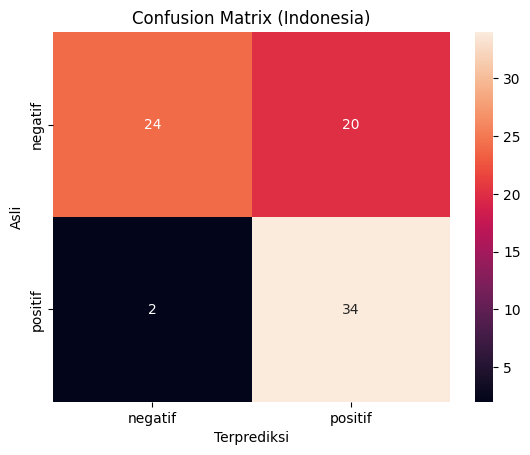

In [14]:
# Bagian Confusion Matrix, untuk mengetahui kesesuaian prediksi 

cm = confusion_matrix(y_test_id, pred_tfidf_id)

labels = sorted(df_id['label'].unique())

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Terprediksi")
plt.ylabel("Asli")
plt.title("Confusion Matrix (Indonesia)")
plt.show()

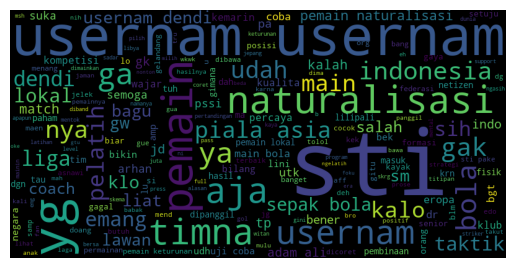

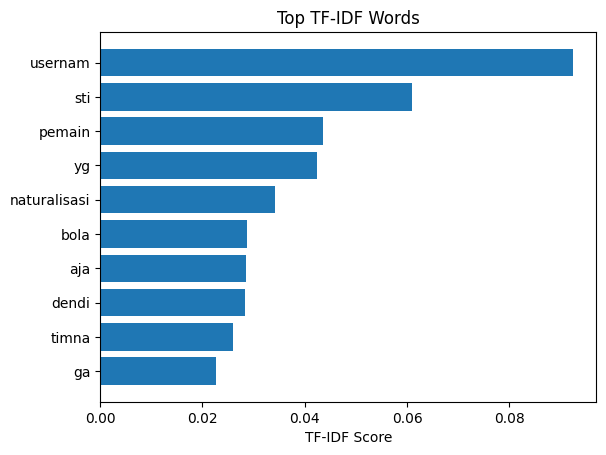

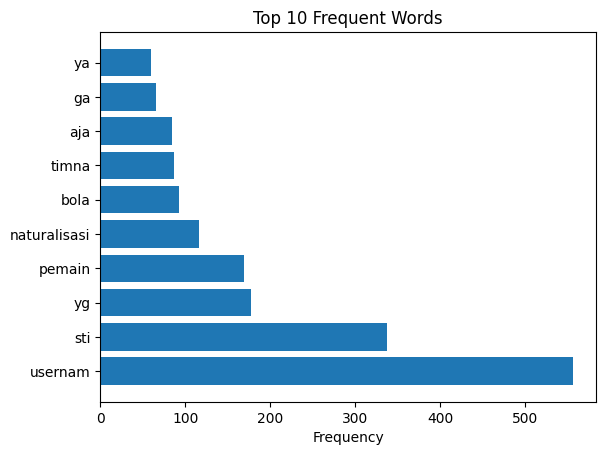

In [15]:
# Visualisasi kata-kata yang cukup sering muncul

text_all = " ".join(df_id['clean_text']) # Menggunakan WordCloud

wc = WordCloud(width=800, height=400).generate(text_all)

plt.imshow(wc)
plt.axis('off')
plt.show()

feature_names = tfidf_id.get_feature_names_out() # Menggunakan Plot TF-IDF

mean_tfidf = X_train_tfidf_id.mean(axis=0).A1

top_n = 10
top_idx = np.argsort(mean_tfidf)[-top_n:]

top_words = [feature_names[i] for i in top_idx]
top_scores = mean_tfidf[top_idx]

plt.figure()
plt.barh(top_words, top_scores)
plt.title("Top TF-IDF Words")
plt.xlabel("TF-IDF Score")
plt.show

words = " ".join(df_id['clean_text']).split() # Menggunakan distribusi frekuensi token
word_counts = Counter(words)

top_words = word_counts.most_common(10)

w = [i[0] for i in top_words]
c = [i[1] for i in top_words]

plt.figure()
plt.barh(w, c)
plt.title("Top 10 Frequent Words")
plt.xlabel("Frequency")
plt.show()

In [16]:
# Hasil Perbandingan

print("=== PERBANDINGAN ===")
print(f"English BoW         : {acc_bow_en}")
print(f"English TF-IDF      : {acc_tfidf_en}")
print(f"Indonesia BoW       : {acc_bow_id}")
print(f"Indonesia TF-IDF    : {acc_tfidf_id}")

=== PERBANDINGAN ===
English BoW         : 0.7142857142857143
English TF-IDF      : 0.6706586826347305
Indonesia BoW       : 0.7375
Indonesia TF-IDF    : 0.725
